In [35]:
import pandas as pd
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset ,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.optim as optim 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [3]:
df=pd.read_csv("powerplant_data (1).csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
#Checking for Missing Values 
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
#as there is No missing Values so we will spli it up 
X=df.drop("PE",axis=1)
y=df["PE"]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.33,random_state=42
)

In [8]:
#Now it is most Important to scale our Data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [9]:
#Now in this step We will convert our Data into Tensors
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [10]:
X_train_set=TensorDataset(X_train_tensor,y_train_tensor)
X_test_set=TensorDataset(X_test_tensor,y_test_tensor)

trainloader=DataLoader(X_train_set)
tesstloader=DataLoader(X_test_set)

In [27]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            #First Hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            #Second Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #Final Output
            nn.Linear(6,1)

        )
    def forward(self,x):
        return self.model(x)


In [28]:
model=ANN()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())


In [ ]:
#Now in this step we will Train our model
train_losses=[]
val_losses=[]
epochs=20
best_val_loss=float("inf")
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for xb,yb in trainloader:
        optimizer.zero_grad()
        output=model(xb)
        loss=criterion(output,yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    epoch_train_loss=running_loss/len(trainloader)
    train_losses.append(epoch_train_loss)
    
    #Model Evaluation
    model.eval()
    running_val_loss=0.0
    
    with torch.no_grad():
        for xb,yb in tesstloader:
            output=model(xb)
            loss=criterion(output,yb)
            running_val_loss+=loss.item()
        epoch_val_loss=running_val_loss/len(tesstloader)
        val_losses.append(epoch_val_loss)
    
    print(f"epoch {epoch+1}/{epochs} epoch train loss {epoch_train_loss} and epoch validation {epoch_val_loss}")
    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"Best_Model.pt")



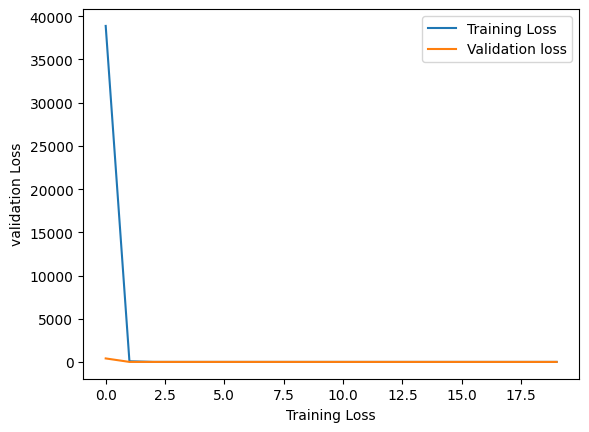

In [31]:
df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses

})
plt.plot(df["Training Loss"],label="Training Loss")
plt.plot(df["Validation Loss"],label="Validation loss")
plt.xlabel("Training Loss")
plt.ylabel("validation Loss")
plt.legend()
plt.show()

In [33]:
#Now How to Load Our best Model
model.load_state_dict(torch.load("Best_Model.pt"))

C:\Users\SP23-BCS-160.CUIATD\AppData\Local\Temp\ipykernel_16984\567092056.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("Best_Model.pt

<All keys matched successfully>

In [37]:
#Model Evaluation 
with torch.no_grad():
    train_pred=model(X_train_tensor)
    test_pred=model(X_test_tensor)
    
    train_mse_loss=criterion(train_pred,y_train_tensor)
    test_mse_loss=criterion(test_pred,y_test_tensor)

print(f"Training Mse: {train_mse_loss.item()}")
print(f"Test Mse: {test_mse_loss.item()}")


Training Mse: 23.06992530822754
Test Mse: 21.647544860839844


In [36]:
print(f"r2 score is {r2_score(y_test,test_pred)}")

r2 score is 0.9253097289946783
